## Import modules

In [28]:
import os

# Get the current working directory (optional, for reference)
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

if current_dir != os.path.join(os.path.dirname(current_dir), "DeepMapper"):
    # Change the current working directory to the parent directory
    os.chdir("..") # ".." is a universal notation for the parent directory

# Verify the change (optional)
print(f"New directory: {os.getcwd()}")

import numpy as np
import torch

import matplotlib
import matplotlib.pyplot as plt

# Training functions
from algs.train import train
# Plotting and data reading functions
from utils.tools import readPercentileMulti, read_all_seed_data

Current directory: e:\GitHubRepos\DeepMapper
New directory: e:\GitHubRepos\DeepMapper


## Start Training

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() and False else "cpu")
imdir = './data/MouseData/'
# imdir = './data/Davinci/'

# Run training for multiple seeds and algorithms
for seed in range(100):
    np.random.seed(seed)
    torch.random.manual_seed(seed)
    # Trian Attention Autoencoder DeepMapper
    train(imdir, seed, alg="AttAE", num_epochs=200)
    # Trian RNN Autoencoder DeepMapper
    train(imdir, seed, alg="RNNAE", num_epochs=200)

## Start Testing

In [16]:
from algs.test import test_trained_model_and_save_data

# Run testing trained models and load data for both algorithms
test_trained_model_and_save_data(alg="RNNAE")
test_trained_model_and_save_data(alg="AttAE")

Testing data for seed 0 and alg RNNAE saved.
Testing data for seed 1 and alg RNNAE saved.
Testing data for seed 0 and alg AttAE saved.
Testing data for seed 1 and alg AttAE saved.


## Load Testing Restuls

In [30]:
ks_A_sds_AttAE = read_all_seed_data(data_dir= "./res/test/DeepMapper_AttAE/predictions/kss/Adult/")
ks_Y_sds_AttAE = read_all_seed_data(data_dir= "./res/test/DeepMapper_AttAE/predictions/kss/Young/")
zs_A_sds_AttAE = read_all_seed_data(data_dir= "./res/test/DeepMapper_AttAE/predictions/stages/Adult/")
zs_Y_sds_AttAE = read_all_seed_data(data_dir= "./res/test/DeepMapper_AttAE/predictions/stages/Young/")

ks_A_sds_RNNAE = read_all_seed_data(data_dir= "./res/test/DeepMapper_RNNAE/predictions/kss/Adult/")
ks_Y_sds_RNNAE = read_all_seed_data(data_dir= "./res/test/DeepMapper_RNNAE/predictions/kss/Young/")
zs_A_sds_RNNAE = read_all_seed_data(data_dir= "./res/test/DeepMapper_RNNAE/predictions/stages/Adult/")
zs_Y_sds_RNNAE = read_all_seed_data(data_dir= "./res/test/DeepMapper_RNNAE/predictions/stages/Young/")

### DeepMapper with Attention based AutoEncodoer Results

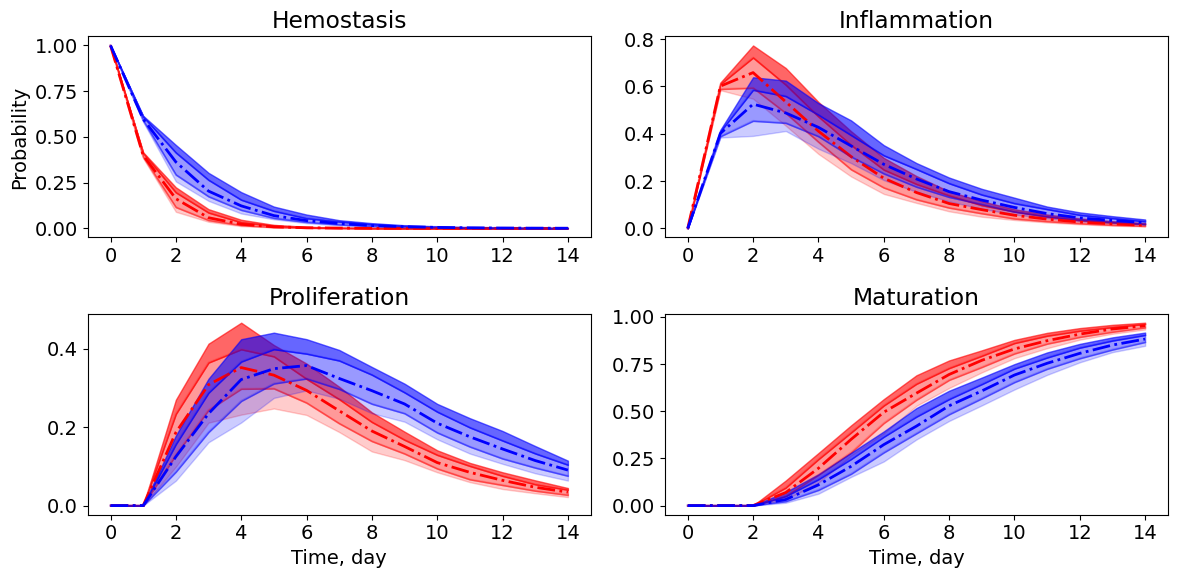

In [22]:
ks_A_median, ks_A_10, ks_A_25, ks_A_75, ks_A_90 = readPercentileMulti(ks_A_sds_AttAE)
ks_Y_median, ks_Y_10, ks_Y_25, ks_Y_75, ks_Y_90 = readPercentileMulti(ks_Y_sds_AttAE)

z_A_median, z_A_10, z_A_25, z_A_75, z_A_90 = readPercentileMulti(zs_A_sds_AttAE)
z_Y_median, z_Y_10, z_Y_25, z_Y_75, z_Y_90 = readPercentileMulti(zs_Y_sds_AttAE)

lname = ['Hemostasis', 'Inflammation', 'Proliferation', 'Maturation']
xrange = range(len(z_A_median[0]))
leg_pos = (1, 1.04)

matplotlib.rcParams.update({'font.size': 14})

fig = plt.figure(num=4, figsize=(12, 6))
for i in range(4):
    ax = fig.add_subplot(2, 2, i + 1)

    ax.set_title(lname[i])
    ax.plot(xrange, z_Y_25[i], color='red', alpha=0.2)
    ax.plot(xrange, z_Y_median[i], color='red', linestyle='-.', linewidth=2, label='T1 Median')
    ax.plot(xrange, z_Y_75[i], color='red', alpha=0.2)
    ax.fill_between(xrange, z_Y_10[i], z_Y_25[i], color='red', alpha=0.2, label='10-25')
    ax.fill_between(xrange, z_Y_25[i], z_Y_75[i], color='red', alpha=0.4, label='25-75')
    ax.fill_between(xrange, z_Y_75[i], z_Y_90[i], color='red', alpha=0.6, label='75-90')

    ax.plot(xrange, z_A_25[i], color='blue', alpha=0.2)
    ax.plot(xrange, z_A_median[i], color='blue', linestyle='-.', linewidth=2, label='T2 Median')
    ax.plot(xrange, z_A_75[i], color='blue', alpha=0.2)
    ax.fill_between(xrange, z_A_10[i], z_A_25[i], color='blue', alpha=0.2, label='10-25')
    ax.fill_between(xrange, z_A_25[i], z_A_75[i], color='blue', alpha=0.4, label='25-75')
    ax.fill_between(xrange, z_A_75[i], z_A_90[i], color='blue', alpha=0.6, label='75-90')

    if i == 2 or i == 3:
        ax.set_xlabel('Time, day')
    if i == 0:
        ax.set_ylabel('Probability')

plt.tight_layout()
# plt.savefig('./res/figs/mouse_zs.pdf', format='pdf')
# plt.savefig('./res/figs/mouse_zs.png', format='png')
# plt.close()



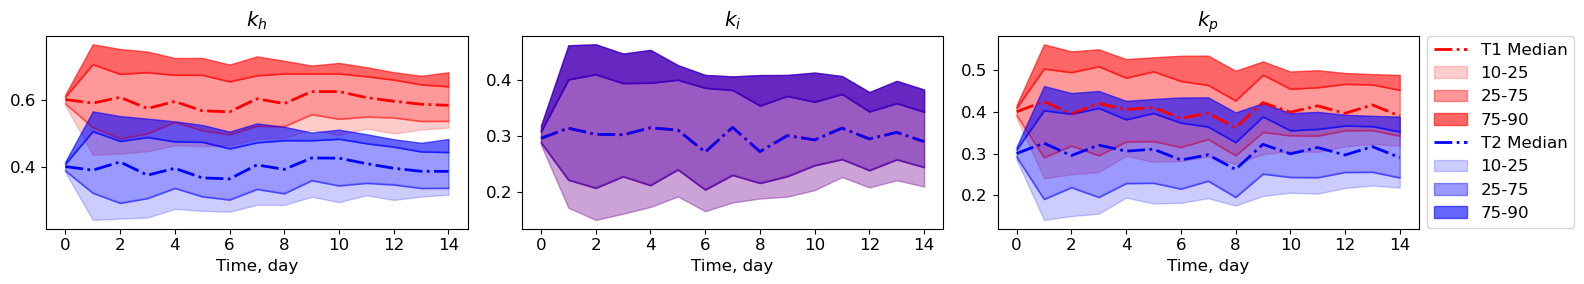

In [23]:
matplotlib.rcParams.update({'font.size': 12})

leg_pos = (1, 1.04)

kname = ['k_h', 'k_i', 'k_p']
fig = plt.figure(num=4, figsize=(16, 3))
for i in range(3):
    ax = fig.add_subplot(1, 3, i + 1)

    ax.set_title(r'${}$'.format(kname[i]))
    ax.plot(xrange, ks_Y_25[i], color='red', alpha=0.2)
    ax.plot(xrange, ks_Y_median[i], color='red', linestyle='-.', linewidth=2, label="T1 Median")
    ax.plot(xrange, ks_Y_75[i], color='red', alpha=0.2)
    ax.fill_between(xrange, ks_Y_10[i], ks_Y_25[i], color='red', alpha=0.2, label='10-25')
    ax.fill_between(xrange, ks_Y_25[i], ks_Y_75[i], color='red', alpha=0.4, label='25-75')
    ax.fill_between(xrange, ks_Y_75[i], ks_Y_90[i], color='red', alpha=0.6, label='75-90')

    # ax.set_title(r'T1 ${}$'.format(kname[i]))
    ax.plot(xrange, ks_A_25[i], color='blue', alpha=0.2)
    ax.plot(xrange, ks_A_median[i], color='blue', linestyle='-.', linewidth=2, label="T2 Median")
    ax.plot(xrange, ks_A_75[i], color='blue', alpha=0.2)
    ax.fill_between(xrange, ks_A_10[i], ks_A_25[i], color='blue', alpha=0.2, label='10-25')
    ax.fill_between(xrange, ks_A_25[i], ks_A_75[i], color='blue', alpha=0.4, label='25-75')
    ax.fill_between(xrange, ks_A_75[i], ks_A_90[i], color='blue', alpha=0.6, label='75-90')

    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=leg_pos)
    # ax.legend(loc='upper left', ncol=2)
    # ax.set_title(lname[i])
    ax.set_xlabel('Time, day')
    # if i == 0:
    #     ax.set_ylabel('Probability')
plt.tight_layout()
# plt.savefig('./res/figs/mouse_ks.pdf', format ='pdf')
# plt.savefig('./res/figs/mouse_ks.png', format='png')
# plt.close()

### DeepMapper with Recurrent Neural Network based AutoEncodoer Results

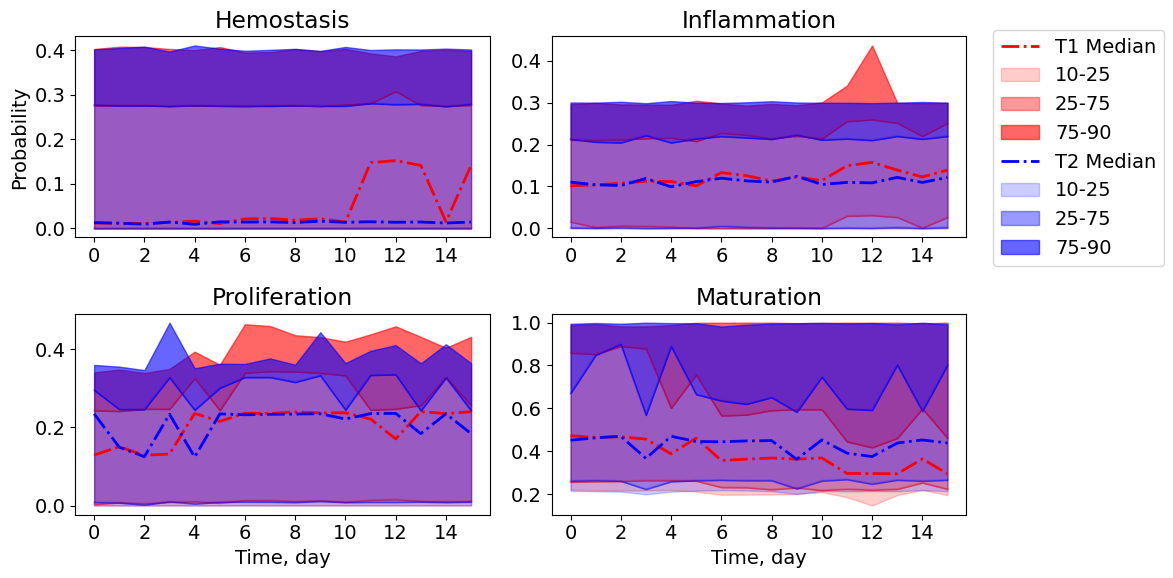

In [50]:
ks_A_median, ks_A_10, ks_A_25, ks_A_75, ks_A_90 = readPercentileMulti(ks_A_sds_RNNAE)
ks_Y_median, ks_Y_10, ks_Y_25, ks_Y_75, ks_Y_90 = readPercentileMulti(ks_Y_sds_RNNAE)

z_A_median, z_A_10, z_A_25, z_A_75, z_A_90 = readPercentileMulti(zs_A_sds_RNNAE)
z_Y_median, z_Y_10, z_Y_25, z_Y_75, z_Y_90 = readPercentileMulti(zs_Y_sds_RNNAE)

lname = ['Hemostasis', 'Inflammation', 'Proliferation', 'Maturation']
xrange = range(len(z_A_median[0]))
leg_pos = (1, 1.04)

matplotlib.rcParams.update({'font.size': 14})

fig = plt.figure(num=4, figsize=(12, 6))
for i in range(4):
    ax = fig.add_subplot(2, 2, i + 1)

    ax.set_title(lname[i])
    ax.plot(xrange, z_Y_25[i], color='red', alpha=0.2)
    ax.plot(xrange, z_Y_median[i], color='red', linestyle='-.', linewidth=2, label='T1 Median')
    ax.plot(xrange, z_Y_75[i], color='red', alpha=0.2)
    ax.fill_between(xrange, z_Y_10[i], z_Y_25[i], color='red', alpha=0.2, label='10-25')
    ax.fill_between(xrange, z_Y_25[i], z_Y_75[i], color='red', alpha=0.4, label='25-75')
    ax.fill_between(xrange, z_Y_75[i], z_Y_90[i], color='red', alpha=0.6, label='75-90')

    ax.plot(xrange, z_A_25[i], color='blue', alpha=0.2)
    ax.plot(xrange, z_A_median[i], color='blue', linestyle='-.', linewidth=2, label='T2 Median')
    ax.plot(xrange, z_A_75[i], color='blue', alpha=0.2)
    ax.fill_between(xrange, z_A_10[i], z_A_25[i], color='blue', alpha=0.2, label='10-25')
    ax.fill_between(xrange, z_A_25[i], z_A_75[i], color='blue', alpha=0.4, label='25-75')
    ax.fill_between(xrange, z_A_75[i], z_A_90[i], color='blue', alpha=0.6, label='75-90')

    if i == 2 or i == 3:
        ax.set_xlabel('Time, day')
    if i == 0:
        ax.set_ylabel('Probability')
    if i == 1:
        ax.legend(bbox_to_anchor=(1.5,1.08), loc='upper right')
    ax.set_xticks([0, 2, 4, 6, 8, 10, 12, 14])
plt.tight_layout()
# plt.savefig('./res/mouse_zs_RNN_pure.pdf', format='pdf')
# plt.savefig('./res/mouse_zs_RNN_pure.png', format='png')
# plt.close()

